Install and import libraries


In [1]:
!pip install pandas scikit-learn nltk transformers datasets kaggle -q

import pandas as pd
import numpy as np
import re
import nltk
import torch
import time
from transformers import Trainer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

Checking GPU

In [2]:
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

GPU available: True
GPU name: Tesla T4


Downloading, loading and inspecting the Airline Dataset from Kaggle

In [3]:
!kaggle datasets download -d crowdflower/twitter-airline-sentiment
!unzip -o twitter-airline-sentiment.zip

df = pd.read_csv("Tweets.csv")
df.head()

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Dataset URL: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment
License(s): CC-BY-NC-SA-4.0
100% 2.55M/2.55M [00:00<00:00, 136MB/s]

Archive:  twitter-airline-sentiment.zip
  inflating: Tweets.csv              
  inflating: database.sqlite         
Shape of dataset: (14640, 15)

Columns:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


Keeping only relevant columns and checking class distribution

In [4]:
df = df[['text', 'airline_sentiment']]
df.head()

print(df['airline_sentiment'].value_counts())

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


Map sentiment labels to numbers

We will use:

negative = 0

neutral = 1

positive = 2

In [5]:
label_map = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

df['label'] = df['airline_sentiment'].map(label_map)
df.head()



,text,airline_sentiment,label
0,@VirginAmerica What @dhepburn said.,neutral,1
1,@VirginAmerica plus you've added commercials t...,positive,2
2,@VirginAmerica I didn't today... Must mean I n...,neutral,1
3,@VirginAmerica it's really aggressive to blast...,negative,0
4,@VirginAmerica and it's a really big bad thing...,negative,0


Define preprocessing function and applying

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)      # remove URLs
    text = re.sub(r"@\w+", "", text)         # remove mentions
    text = re.sub(r"#", "", text)            # remove hashtag sign but keep word
    text = re.sub(r"[^\w\s]", "", text)      # remove punctuation
    text = re.sub(r"\s+", " ", text).strip() # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head(10)

df = df.sample(5000, random_state=42).reset_index(drop=True)

print("Dataset reduced for fair comparison:", df.shape)

Dataset reduced for fair comparison: (5000, 4)


Split dataset into train and test

In [7]:
X = df['clean_text']
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 4000
Testing samples: 1000


Model 1: VADER (Lexicon-based)

In [8]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 2   # positive
    elif score <= -0.05:
        return 0   # negative
    else:
        return 1   # neutral

start_time = time.time()
y_pred_vader = X_test_text.apply(vader_predict)
vader_time = time.time() - start_time

print("VADER predictions completed.")
print("Time taken (seconds):", round(vader_time, 4))

print("VADER Accuracy:", round(accuracy_score(y_test, y_pred_vader), 4))
print("VADER Precision:", round(precision_score(y_test, y_pred_vader, average='weighted'), 4))
print("VADER Recall:", round(recall_score(y_test, y_pred_vader, average='weighted'), 4))
print("VADER F1 Score:", round(f1_score(y_test, y_pred_vader, average='weighted'), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_vader, target_names=['negative', 'neutral', 'positive']))

VADER predictions completed.
Time taken (seconds): 0.1714
VADER Accuracy: 0.54
VADER Precision: 0.7028
VADER Recall: 0.54
VADER F1 Score: 0.5614

Classification Report:

              precision    recall  f1-score   support

    negative       0.90      0.49      0.63       637
     neutral       0.36      0.43      0.39       204
    positive       0.34      0.90      0.50       159

    accuracy                           0.54      1000
   macro avg       0.54      0.61      0.51      1000
weighted avg       0.70      0.54      0.56      1000



Model 2: TF-IDF + Logistic Regression

In [9]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

lr_model = LogisticRegression(max_iter=1000)

start_time = time.time()
lr_model.fit(X_train_tfidf, y_train)
lr_train_time = time.time() - start_time

print("Logistic Regression training completed.")
print("Training time (seconds):", round(lr_train_time, 4))

start_time = time.time()
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_inference_time = time.time() - start_time

print("Logistic Regression predictions completed.")
print("Inference time (seconds):", round(lr_inference_time, 4))

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Logistic Regression Precision:", round(precision_score(y_test, y_pred_lr, average='weighted'), 4))
print("Logistic Regression Recall:", round(recall_score(y_test, y_pred_lr, average='weighted'), 4))
print("Logistic Regression F1 Score:", round(f1_score(y_test, y_pred_lr, average='weighted'), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=['negative', 'neutral', 'positive']))

TF-IDF train shape: (4000, 5000)
TF-IDF test shape: (1000, 5000)
Logistic Regression training completed.
Training time (seconds): 0.8781
Logistic Regression predictions completed.
Inference time (seconds): 0.0008
Logistic Regression Accuracy: 0.78
Logistic Regression Precision: 0.7816
Logistic Regression Recall: 0.78
Logistic Regression F1 Score: 0.7552

Classification Report:

              precision    recall  f1-score   support

    negative       0.77      0.97      0.86       637
     neutral       0.74      0.37      0.49       204
    positive       0.87      0.54      0.67       159

    accuracy                           0.78      1000
   macro avg       0.79      0.63      0.67      1000
weighted avg       0.78      0.78      0.76      1000



Compare VADER vs Logistic Regression

In [10]:
results = pd.DataFrame({
    'Model': ['VADER', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_vader),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Precision': [
        precision_score(y_test, y_pred_vader, average='weighted'),
        precision_score(y_test, y_pred_lr, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_vader, average='weighted'),
        recall_score(y_test, y_pred_lr, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_vader, average='weighted'),
        f1_score(y_test, y_pred_lr, average='weighted')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,VADER,0.54,0.702827,0.54,0.561425
1,Logistic Regression,0.78,0.781617,0.78,0.755169


Model 3: BERT

In [11]:
# =========================
# BERT FULL SETUP (FINAL CORRECT VERSION)
# =========================

from datasets import Dataset
from transformers import BertTokenizer, BertForSequenceClassification

# ✅ USE SAME SPLIT (DO NOT RESPLIT)
# X_train_text, X_test_text, y_train, y_test already exist

# 1. Convert to HuggingFace dataset
train_df = pd.DataFrame({
    'text': X_train_text,
    'label': y_train
})

test_df = pd.DataFrame({
    'text': X_test_text,
    'label': y_test
})

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

# 2. Load tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 3. Tokenization function
def tokenize(example):
    return tokenizer(
        example['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

# 4. Apply tokenization
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# 5. Set PyTorch format
train_dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label']
)

test_dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label']
)

# 6. Load BERT model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

print("✅ BERT setup complete with SAME dataset split.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT setup complete with SAME dataset split.


Training the model

In [12]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    logging_dir='./logs',
    report_to="none"
)

print("✅ Training arguments ready")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

predictions = trainer.predict(test_dataset)

y_pred_bert = predictions.predictions.argmax(axis=1)
y_true_bert = y_test.values

print("BERT Accuracy:", accuracy_score(y_true_bert, y_pred_bert))
print("BERT Precision:", precision_score(y_true_bert, y_pred_bert, average='weighted'))
print("BERT Recall:", recall_score(y_true_bert, y_pred_bert, average='weighted'))
print("BERT F1:", f1_score(y_true_bert, y_pred_bert, average='weighted'))

print(classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=['negative', 'neutral', 'positive']
))



`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Training arguments ready


Step,Training Loss
500,0.583940
1000,0.321508


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT Accuracy: 0.844
BERT Precision: 0.83828509048409
BERT Recall: 0.844
BERT F1: 0.836682807398703
              precision    recall  f1-score   support

    negative       0.87      0.95      0.91       637
     neutral       0.77      0.57      0.66       204
    positive       0.80      0.76      0.78       159

    accuracy                           0.84      1000
   macro avg       0.81      0.76      0.78      1000
weighted avg       0.84      0.84      0.84      1000



Results:

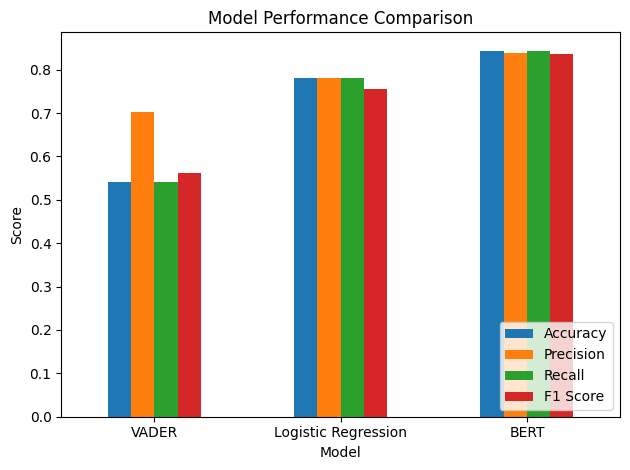

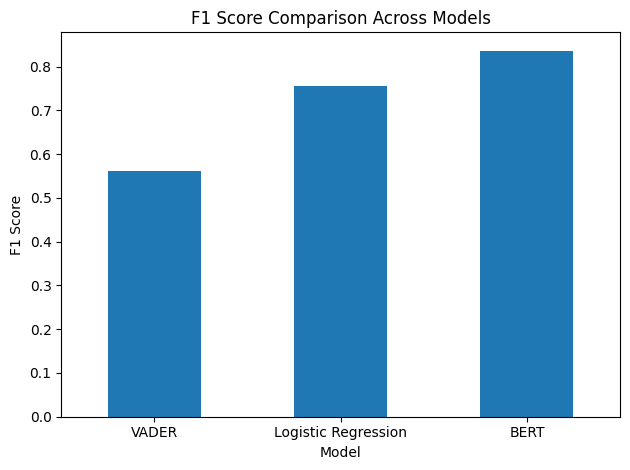

In [13]:
final_results = pd.DataFrame({
    'Model': ['VADER', 'Logistic Regression', 'BERT'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_vader),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_true_bert, y_pred_bert)
    ],
    'Precision': [
        precision_score(y_test, y_pred_vader, average='weighted'),
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_true_bert, y_pred_bert, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_vader, average='weighted'),
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_true_bert, y_pred_bert, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_vader, average='weighted'),
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_true_bert, y_pred_bert, average='weighted')
    ]
})

final_results

import matplotlib.pyplot as plt

# Set index for better plotting
final_results.set_index('Model', inplace=True)

final_results.plot(kind='bar')

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

final_results['F1 Score'].plot(kind='bar')

plt.title("F1 Score Comparison Across Models")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

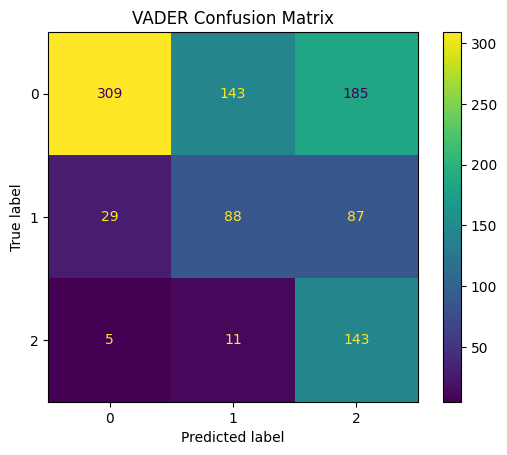

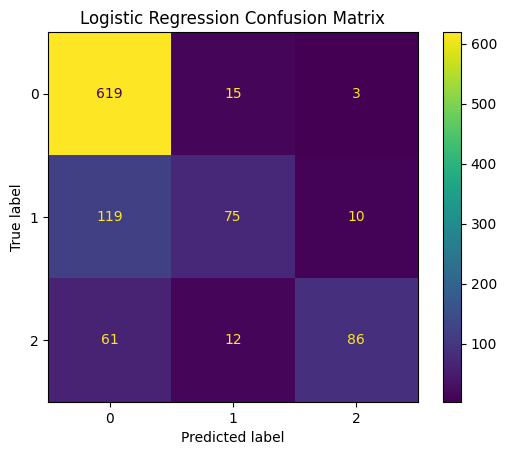

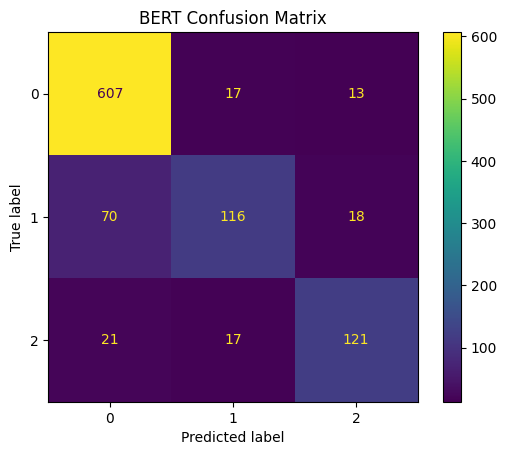

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

# VADER
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_vader)
plt.title("VADER Confusion Matrix")
plt.show()

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# BERT
ConfusionMatrixDisplay.from_predictions(y_true_bert, y_pred_bert)
plt.title("BERT Confusion Matrix")
plt.show()